# Setup and Imports


In [14]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Add src folder to the path
sys.path.append(os.path.abspath('../src'))

from data_utils import load_bitstream, apply_error_correction
from modulator import (
    apply_tukey_window,
    map_bits_to_symbols,
    normalize_audio,
    pulse_shape_symbols,
    to_int16_pcm,
    upconvert_to_passband,
)
from plot_utils import plot_complex_parts, plot_fft, plot_waveform, save_important_plot
from sync import assemble_baseband_frame, generate_zadoff_chu_audio

import config 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [15]:
FS = config.FS           # Sample rate (Hz)
F_CARRIER = config.F_CARRIER     # Center frequency 

SYMBOL_RATE = config.SYMBOL_RATE     # Symbols per second (Baud)

SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL

print(f"Carrier Frequency: {F_CARRIER} Hz")
print(f"Symbol Rate: {SYMBOL_RATE} Baud")
print(f"Samples per Symbol: {SAMPLES_PER_SYMBOL}")
print(f"tthis is inaccurate for sinc pulse, Main Lobe Bandwidth: ~{2 * SYMBOL_RATE} Hz (From {F_CARRIER - SYMBOL_RATE} Hz to {F_CARRIER + SYMBOL_RATE} Hz)")


Carrier Frequency: 10000 Hz
Symbol Rate: 6300 Baud
Samples per Symbol: 7
tthis is inaccurate for sinc pulse, Main Lobe Bandwidth: ~12600 Hz (From 3700 Hz to 16300 Hz)


# QAM Modulation


In [16]:
M = config.M  # Change to 4, 16, 64, or 256
bits_per_symbol = int(np.log2(M))

# Let's generate enough bits for few symbols
total_bits = config.total_symbols * bits_per_symbol

input_path = "../data/message.txt"  # need to make a program which converts the message to bits
read_flag = config.flag

if read_flag:
    if not os.path.exists(input_path):
        raise FileNotFoundError("message.txt not found")

    with open(input_path, "r") as f:
        content = f.read().strip()

    if len(content) == 0:
        raise ValueError("File is empty. Cannot read message bits.")

    message_bits = np.array(list(map(int, content)))
else:
    message_bits = np.random.randint(0, 2, total_bits)

    with open(input_path, "w") as f:
        f.write("".join(map(str, message_bits)))

qam_symbols = map_bits_to_symbols(message_bits, M, METHOD=config.modulation_method)
print(f"Generated {len(qam_symbols)} complex symbols for {M}-{config.modulation_method}.")


Generated 4 complex symbols for 4-QAM.


# Baseband Pulse Shaping, Pilots, and Frame Assembly


In [17]:
len_zadoff_chu = config.len_zadoff_chu
u_zadoff_chu = config.u_zadoff_chu

sync_audio = generate_zadoff_chu_audio(len_zadoff_chu, u_zadoff_chu)


pilot_bits = config.pilot_bits
pilot_symbols = map_bits_to_symbols(pilot_bits, M, METHOD=config.modulation_method)
baseband_symbols = np.concatenate((pilot_symbols, qam_symbols))

print(pilot_symbols)

baseband_signal = pulse_shape_symbols(baseband_symbols, SAMPLES_PER_SYMBOL,METHOD=config.pulse_method)
print(len(baseband_symbols))
print("Used ",config.pulse_method," for pulse shapping")


[ 0.70710678-0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678-0.70710678j  0.70710678+0.70710678j
 -0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678+0.70710678j
 -0.70710678-0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678+0.70710678j]
20
Used  SINC  for pulse shapping


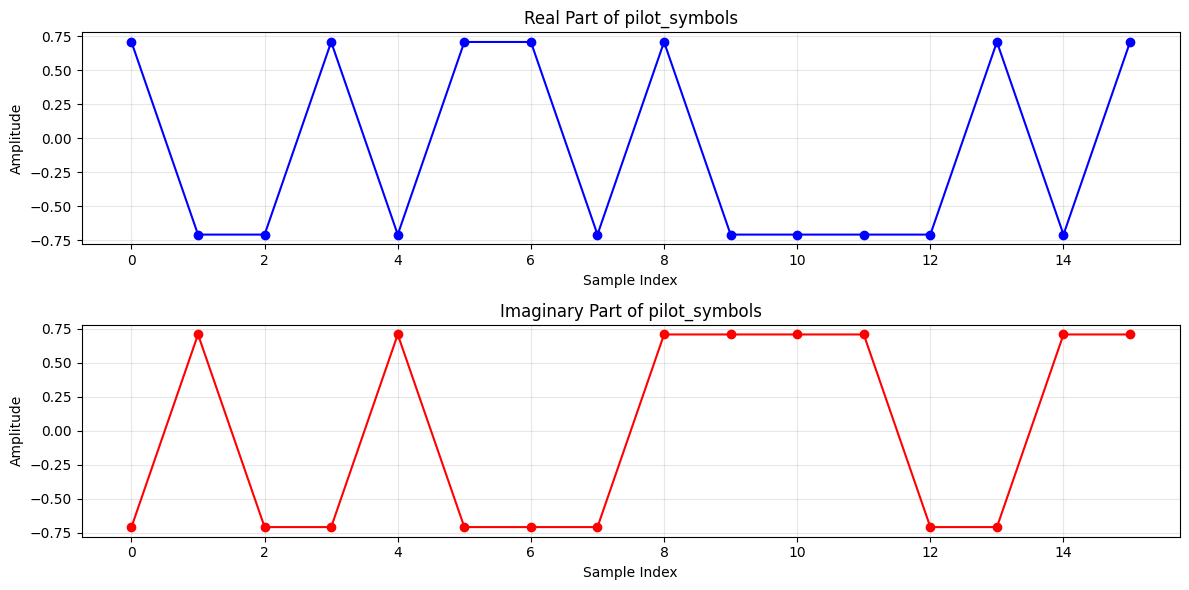

In [18]:
plot_complex_parts(pilot_symbols, title_prefix="pilot_symbols")
plt.show()

In [19]:
pilot_signal = pulse_shape_symbols(pilot_symbols, SAMPLES_PER_SYMBOL,METHOD=config.pulse_method)

baseband_transmission = assemble_baseband_frame(
    sync_audio=sync_audio,
    payload_signal=baseband_signal,
    fs=FS,
    start_silence=5.0,
    middle_silence=config.SYNC_GAP_SECONDS,
    end_silence=3.0,
)


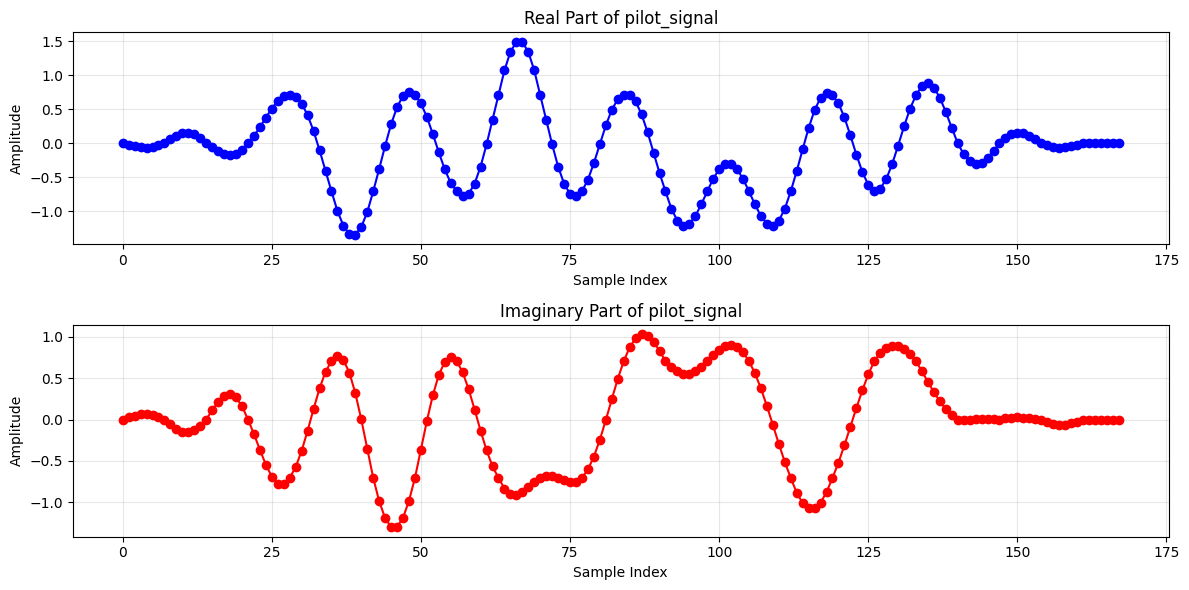

In [20]:
plot_complex_parts(pilot_signal, title_prefix="pilot_signal")
plt.show()

# Passband Modulation and WAV Export


Data payload successfully modulated to passband audio.
Saved transmission file to: ../data/tx_single_carrier_test.wav


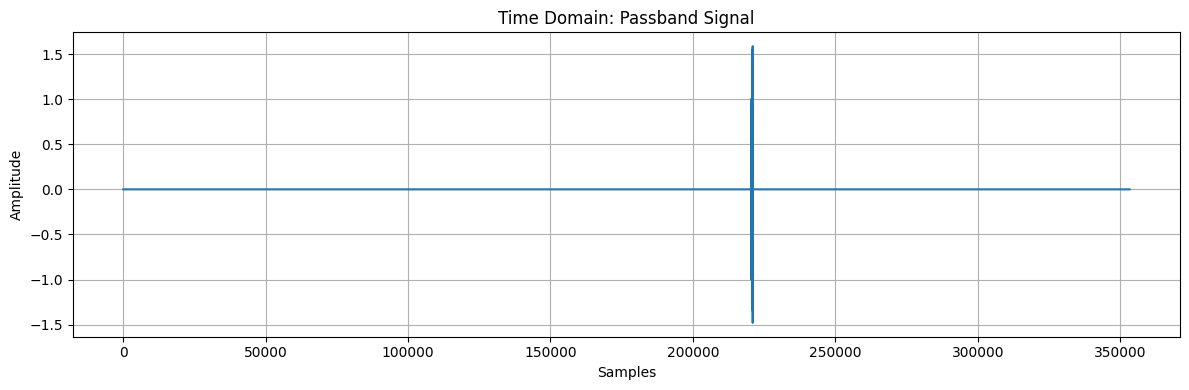

In [8]:
passband_signal = upconvert_to_passband(baseband_transmission, FS, F_CARRIER)
transmission_signal = apply_tukey_window(passband_signal, alpha=0.01)
print("Data payload successfully modulated to passband audio.")

transmission_signal = normalize_audio(transmission_signal)
transmission_signal_16bit = to_int16_pcm(transmission_signal)

output_path = "../data/tx_single_carrier_test.wav"
wavfile.write(output_path, FS, transmission_signal_16bit)
print(f"Saved transmission file to: {output_path}")

plot_waveform(passband_signal, title="Time Domain: Passband Signal")
plt.show()


# Quick Checks


checking if autocorrelation of passband isnt ruined

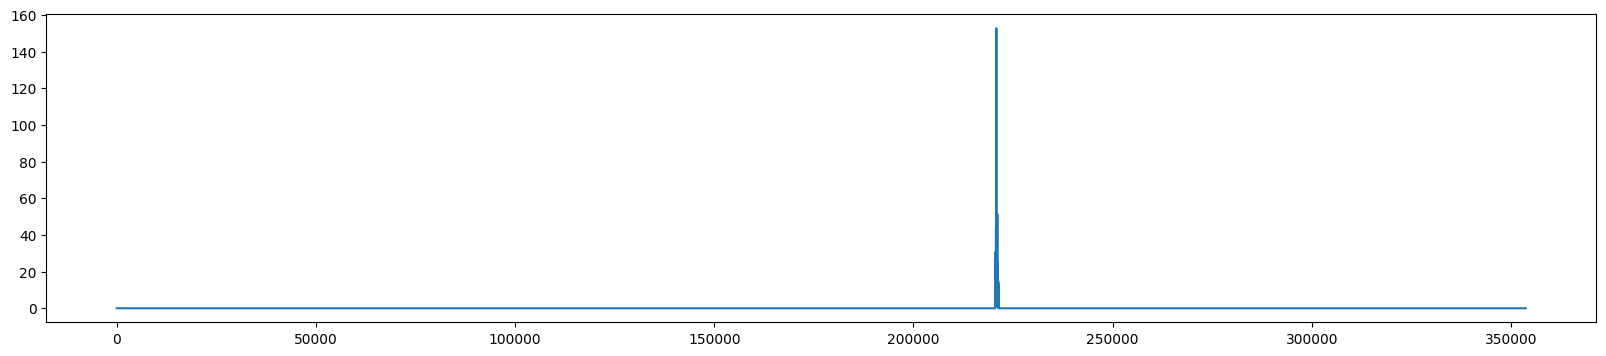

220712


In [9]:
corr = np.correlate(passband_signal, sync_audio, mode="full")
plt.figure(figsize=(20, 4))
plt.plot(abs(corr))
plt.show()
print(np.argmax(corr))

sample rate of the audio signal is  44100


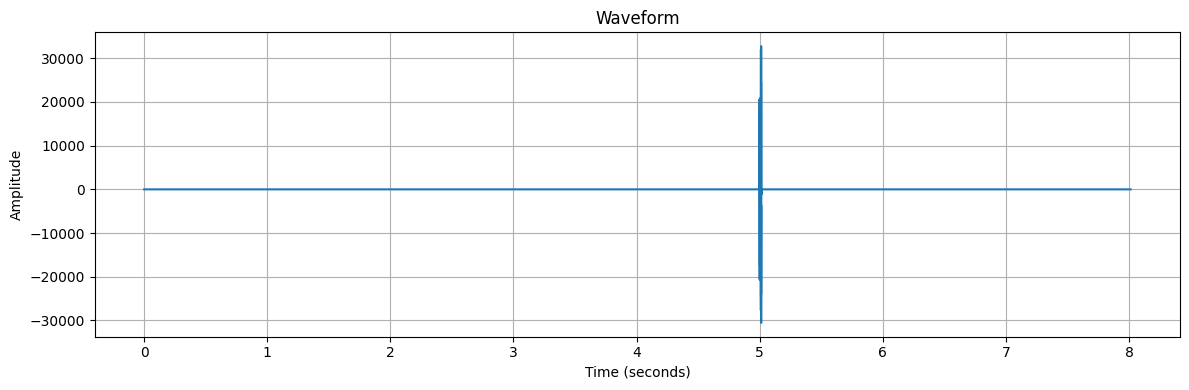

In [10]:
sample_rate, data = wavfile.read("../data/tx_single_carrier_test.wav")
print("sample rate of the audio signal is ",sample_rate)
plot_waveform(data, sample_rate=sample_rate, title="Waveform")
plt.show()

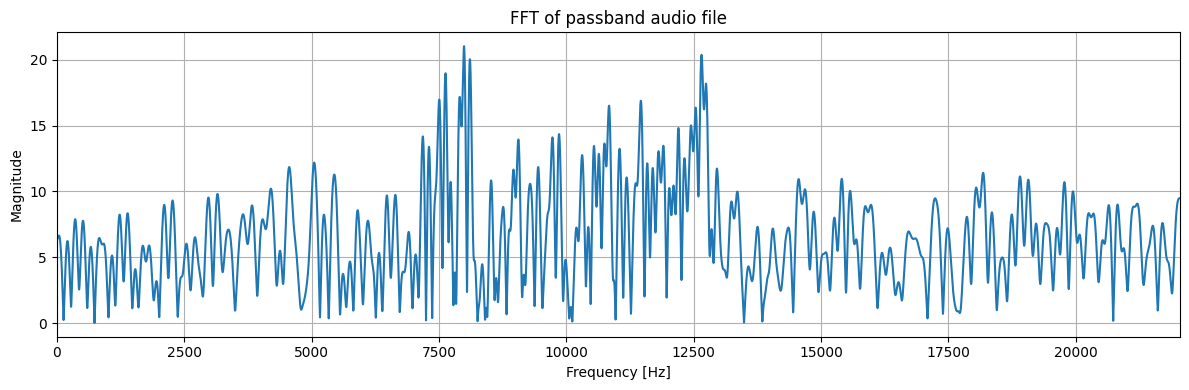

In [11]:
fs_read, audio_data = wavfile.read(output_path)
plot_fft(audio_data, fs_read, title="FFT of passband audio file")
plt.show()

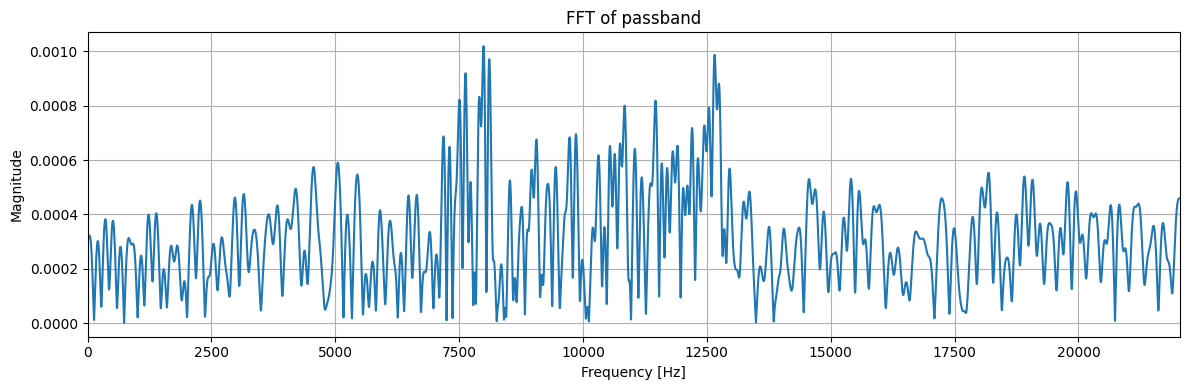

In [12]:
fig, ax = plot_fft(passband_signal, FS, title="FFT of passband")
save_important_plot("fft_passband_signal", fig)
plt.show()


In [13]:
""" fig, ax = plot_fft(baseband_signal, FS, title="FFT of baseband")
save_important_plot("fft_baseband_signal", fig)
plt.show()
 """

' fig, ax = plot_fft(baseband_signal, FS, title="FFT of baseband")\nsave_important_plot("fft_baseband_signal", fig)\nplt.show()\n '